  #  Akomolafe Nathaniel Iyanuoluwa Data Science Car Price Prediction with Machine Learning 
**Objective:** Predict the selling price of a used car from features such as brand, age, mileage, fuel type, and transmission.

**Dataset:** Vehicle dataset from CarDekho (301 used car listings: name, year, selling price, present price, kms driven, fuel type, seller type, transmission, owner).

# Loading the  Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

Car_Price = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_data.csv")
Car_Price.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Dataset:** Vehicle dataset from CarDekho (301 used car listings: name, year, selling price, present price, kms driven, fuel type, seller type, transmission, owner).

# Data Cleaning

In [15]:
# Checking for missing values, duplicates, and data types

display(Markdown("## Shape"))
display(Car_Price.shape)

display(Markdown("## Null Values"))
display(Car_Price.isnull().sum().to_frame("Null Count"))

display(Markdown("## Duplicate Rows"))
display(Car_Price.duplicated().sum())

Car_Price = Car_Price.drop_duplicates().reset_index(drop=True)

## Shape

(301, 9)

## Null Values

,Null Count
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


## Duplicate Rows

np.int64(2)

In [16]:
# Normalizing categorical text values (consistent casing)

for c in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    Car_Price[c] = Car_Price[c].astype(str).str.strip().str.title()


pd.DataFrame({
    'Fuel_Type': pd.Series(Car_Price['Fuel_Type'].unique()),
    'Seller_Type': pd.Series(Car_Price['Seller_Type'].unique()),
    'Transmission': pd.Series(Car_Price['Transmission'].unique())
})

,Fuel_Type,Seller_Type,Transmission
0,Petrol,Dealer,Manual
1,Diesel,Individual,Automatic
2,Cng,NaN,NaN


# Feature Engineering

In [17]:

CURRENT_YEAR = 2020  # dataset's last recorded year context
Car_Price['Car_Age'] = CURRENT_YEAR - Car_Price['Year']

# "Brand" extraction from the car name (first word, e.g. 'ritz' / 'city' style names are model names here;
# for this dataset Car_Name is mostly the model, so we treat the first token as a brand/model proxy)
Car_Price['Brand'] = Car_Price['Car_Name'].astype(str).str.split().str[0].str.lower()

Car_Price[['Car_Name', 'Brand', 'Year', 'Car_Age']].head()


,Car_Name,Brand,Year,Car_Age
0,ritz,ritz,2014,6
1,sx4,sx4,2013,7
2,ciaz,ciaz,2017,3
3,wagon r,wagon,2011,9
4,swift,swift,2014,6


**Note:** This particular CarDekho extract lists model names (e.g. "ritz", "sx4", "ciaz") rather than full "Make Model" strings, so the extracted first token acts as a model-level grouping proxy for brand-style analysis.

# Exploratory Data Analysis

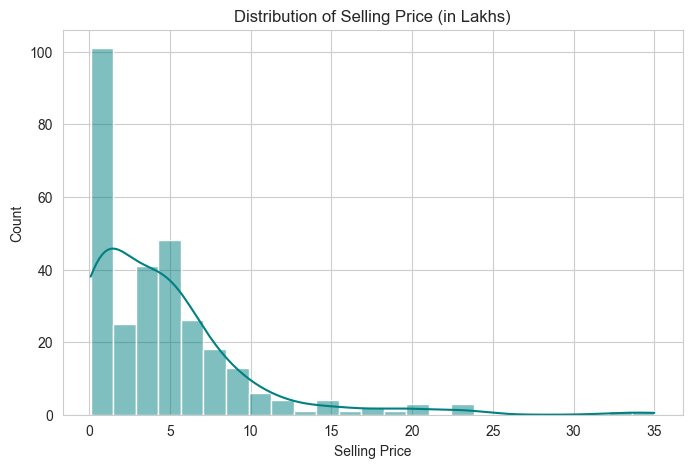

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(Car_Price['Selling_Price'], kde=True, bins=25, color='teal')
plt.title('Distribution of Selling Price (in Lakhs)')
plt.xlabel('Selling Price')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_price_Distribution.png",
            dpi=300,
            bbox_inches='tight')
plt.show()


C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_16360\2287324715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Car_Price, x='Fuel_Type', y='Selling_Price', palette='Set2')


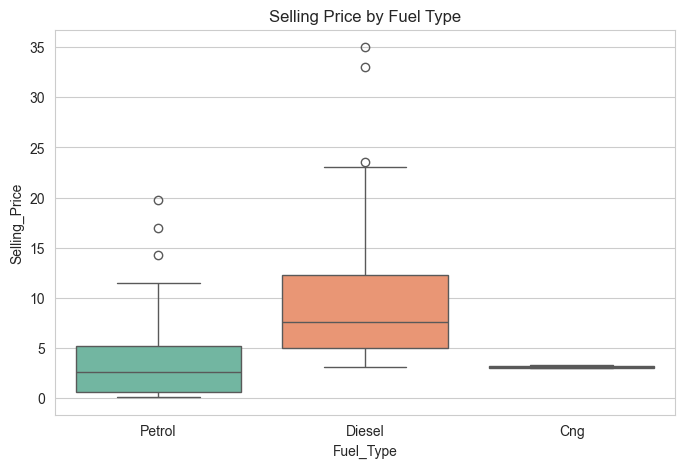

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Car_Price, x='Fuel_Type', y='Selling_Price', palette='Set2')
plt.title('Selling Price by Fuel Type')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_price_Boxplot.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

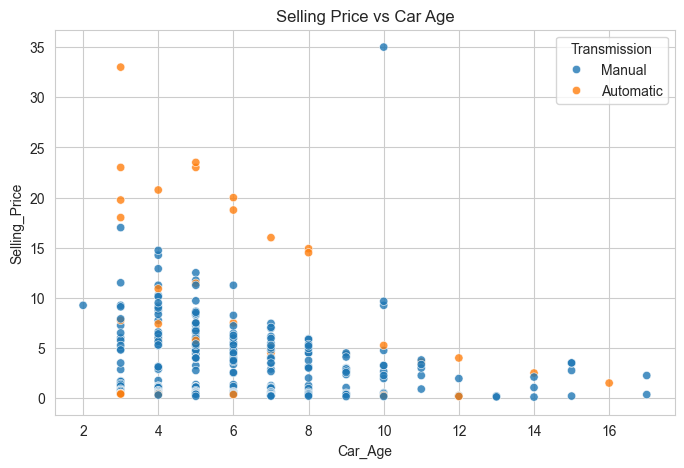

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=Car_Price, x='Car_Age', y='Selling_Price', hue='Transmission', alpha=0.8)
plt.title('Selling Price vs Car Age')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_price_Scatterplot.png",
            dpi=300,
            bbox_inches='tight')
plt.show()


**Observation:** Selling price is right-skewed (most cars cluster at lower price points, with a long tail of premium cars). Diesel cars tend to command a higher median selling price than Petrol or CNG. Selling price clearly declines as car age increases, confirming the expected depreciation pattern.

# Encoding Categorical Variables

In [21]:

Car_Price_encoded = Car_Price.copy()
le_fuel = LabelEncoder()
le_seller = LabelEncoder()
le_trans = LabelEncoder()

Car_Price_encoded['Fuel_Type_enc'] = le_fuel.fit_transform(Car_Price_encoded['Fuel_Type'])
Car_Price_encoded['Seller_Type_enc'] = le_seller.fit_transform(Car_Price_encoded['Seller_Type'])
Car_Price_encoded['Transmission_enc'] = le_trans.fit_transform(Car_Price_encoded['Transmission'])

Car_Price_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand,Fuel_Type_enc,Seller_Type_enc,Transmission_enc
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6,ritz,2,0,1
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7,sx4,1,0,1
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3,ciaz,2,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9,wagon,2,0,1
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6,swift,1,0,1


## Feature Correlation Heatmap

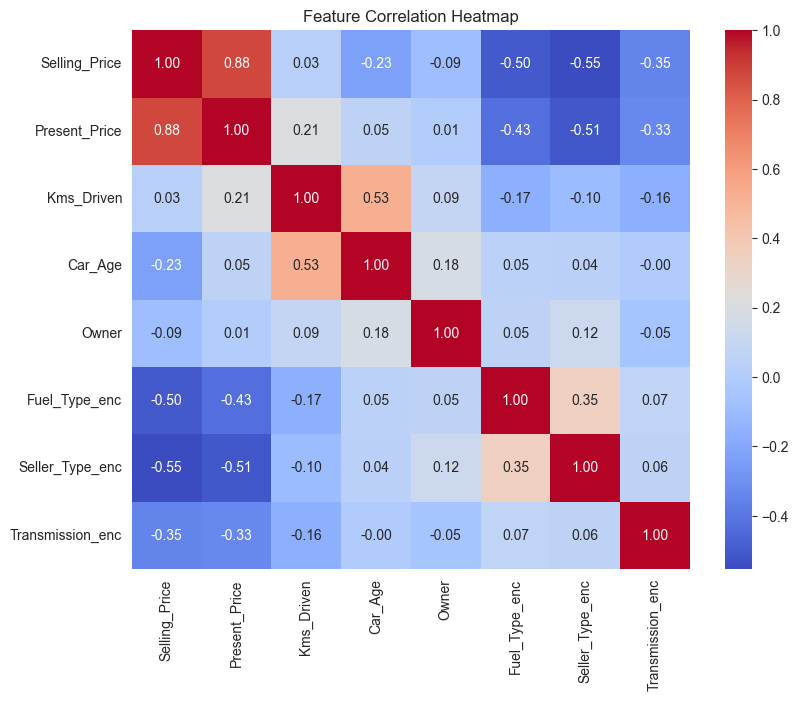

In [22]:

numeric_features = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Owner',
                    'Fuel_Type_enc', 'Seller_Type_enc', 'Transmission_enc']
corr = Car_Price_encoded[numeric_features].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_price_Correlation_Heatmap.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** `Present_Price` (current ex-showroom price) is by far the strongest predictor of `Selling_Price`, as expected newer, pricier models retain higher resale value. `Car_Age` shows a clear negative correlation with selling price.

## Train/Test Split

In [23]:

features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner',
            'Fuel_Type_enc', 'Seller_Type_enc', 'Transmission_enc']
X = Car_Price_encoded[features]
y = Car_Price_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

,Dataset,Rows,Columns
0,Training,239,7
1,Testing,60,7


## Training Regression Models

In [24]:

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'mae': mae, 'rmse': rmse, 'r2': r2}
    results_model = (
    pd.DataFrame(results)
    .T                           # Transpose so models become rows
    .reset_index()
    .rename(columns={
        "index": "Model",
        "mae": "MAE",
        "rmse": "RMSE",
        "r2": "R² Score"
    })
)

results_model = results_model[
    ["Model", "MAE", "RMSE", "R² Score"]
].round(3)

results_model = results_model.sort_values(
    by="R² Score",
    ascending=False
)

results_model

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.541072,2.583242,0.741083
2,Gradient Boosting Regressor,1.169234,2.666754,0.724071
1,Random Forest Regressor,1.482684,3.522024,0.518701


## Model Evaluation Summary

In [25]:
comparison = pd.DataFrame({
    name: {'MAE': r['mae'], 'RMSE': r['rmse'], 'R2': r['r2']}
    for name, r in results.items()
}).T
comparison
best_name = comparison['R2'].idxmax()
print(f"Best performing model: {best_name}")
best_model = results[best_name]['model']

Best performing model: Linear Regression


## Feature Importance (Best Model)

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_16360\215227995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


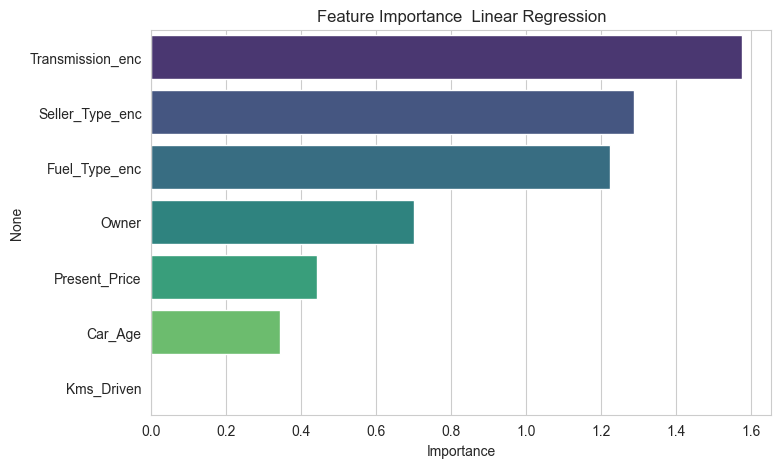

Transmission_enc    1.576618
Seller_Type_enc     1.289676
Fuel_Type_enc       1.223848
Owner               0.700680
Present_Price       0.441316
Car_Age             0.343075
Kms_Driven          0.000009
dtype: float64

In [26]:

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(best_model.coef_), index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title(f'Feature Importance  {best_name}')
plt.xlabel('Importance')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 3\car_price_Feature_Importance.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

importances

## Conclusion

`Present_Price` dominates as the single most important predictor unsurprising, since a car's original showroom price anchors its resale value. `Car_Age` and `Kms_Driven` are the next most influential, consistent with standard depreciation expectations. Categorical factors (fuel type, seller type, transmission) contribute comparatively less but still provide incremental predictive value, especially for distinguishing Diesel vs Petrol price premiums.